# Implementing Plug-and-play DRUNet regularization from DeepInverse with Half Quadratic Splitting in STIR


### This notebook is an example of how to integrate learned regularization components from [DeepInverse](https://deepinv.github.io/deepinv/index.html) together with the optimization procedures in [SIRF](https://github.com/SyneRBI/SIRF/blob/master/doc/DeveloperGuide.md). 

This notebook implements a Half Quadratic Splitting algorithm for PET image reconstruction, using tomographic reconstruction components from SIRF, and wrapping learned regularization components from DeepInverse to be compatible with SIRF's optimization routines.

## Set up the reconstruction problem

In [ ]:
import os
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
import sirf.STIR as pet
from sirf.Utilities import examples_data_path
from tqdm import tqdm
import torch
from deepinv.models import DRUNet

msg_red = pet.MessageRedirector('info.txt', 'warnings.txt', 'errors.txt')

data_path = os.path.join(examples_data_path('PET'), 'thorax_single_slice')

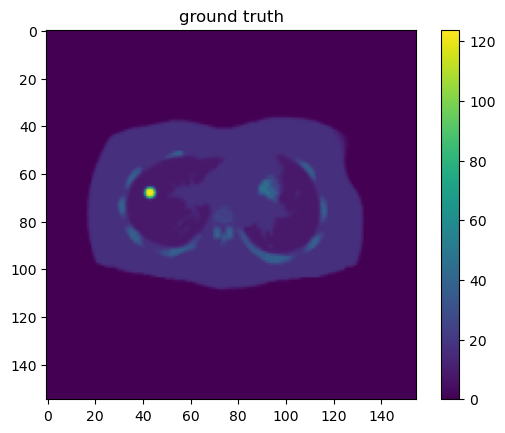

In [ ]:
def make_cylindrical_fov(image):
    arr = image.as_array()
    nz, ny, nx = arr.shape
    yy, xx = np.ogrid[:ny, :nx]
    cy, cx = (ny - 1) / 2.0, (nx - 1) / 2.0
    radius = min(nx, ny) / 2.0
    mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= radius ** 2
    arr *= mask[None, :, :]
    image.fill(arr)
    return image
    
def build_problem(count_scale_factor=2.0):
    image = pet.ImageData(os.path.join(data_path, 'emission.hv')) * count_scale_factor
    template = pet.AcquisitionData(os.path.join(data_path, 'template_sinogram.hs'))

    acq_model = pet.AcquisitionModelUsingRayTracingMatrix()
    acq_model.set_num_tangential_LORs(5)
    acq_model.set_up(template, image)

    clean_data = acq_model.forward(image)
    acquired_data = clean_data.clone()
    acquired_data.fill(np.random.poisson(clean_data.as_array()).astype(np.float32))

    obj_fun = pet.make_Poisson_loglikelihood(acquired_data)
    obj_fun.set_acquisition_model(acq_model)

    initial = image.get_uniform_copy(image.max() * 0.15)
    make_cylindrical_fov(initial)

    if hasattr(obj_fun, 'set_num_subsets'):
        obj_fun.set_num_subsets(1)
    if hasattr(obj_fun, 'set_up'):
        obj_fun.set_up(initial)

    return image, acquired_data, acq_model, obj_fun, initial

ground_truth, acquired_data, acq_model, obj_fun, x = build_problem()

plt.imshow(ground_truth.as_array()[0,:,:])
plt.colorbar()
plt.title('ground truth')
plt.show()


## Set up data fidelity operator with STIR

In [ ]:
from cil.optimisation.algorithms import PDHG
from cil.optimisation.functions import KullbackLeibler, Function

f = KullbackLeibler(b=acquired_data, eta=(acquired_data * 0 + 1e-5))
K = acq_model
normK = K.norm()

## Set up hyperparameters

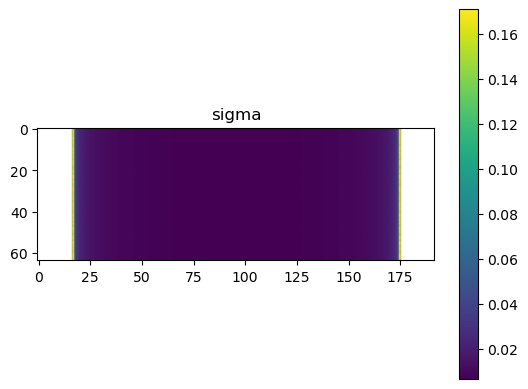

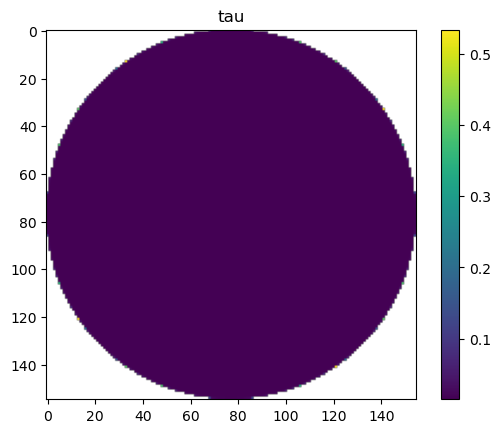

In [4]:
ones_data = acquired_data.clone().fill(1)
ones_image = ground_truth.clone().fill(1)

gamma = 1
sigma = gamma*ones_data/acq_model.get_linear_acquisition_model().forward(ones_image)
tau = 1/gamma*ones_image/acq_model.backward(ones_data)

plt.imshow(sigma.as_array()[0,0,:,:])
plt.colorbar()
plt.title('sigma')
plt.show()

plt.imshow(tau.as_array()[0,:,:])
plt.colorbar()
plt.title('tau')
plt.show()


## Implement Plug-and-play DRUNET wrapper for CIL/SIRF/STIR images 

In [ ]:
from deepinv.models import DRUNet
from deepinv.models import EquivariantDenoiser

class DRUNetPnP(Function):
    """
    Plug-and-play DRUNet wrapper for CIL/SIRF/STIR images with shape (1, H, W).
    Must implement the `__call__`, `gradient` and `proximal` function signatures.
    Only `proximal` is used by the PDHG algorithm.
    """
    def __init__(
        self,
        model=None,
        device=None,
        sigma=10.0,      # DRUNet noise level in [0,255] convention
        clamp=True,      # clamp normalized image to [0,1] before/after denoising
        eps=1e-12,
    ):
        super().__init__()

        self.device = torch.device(
            device if device is not None else ("cuda" if torch.cuda.is_available() else "cpu")
        )

        # Initialize the denoising model from DeepInverse, and implement it as an equivariant denoiser
        self.model = DRUNet(pretrained="download", in_channels=1, out_channels=1) if model is None else model
        self.model = EquivariantDenoiser(self.model)
        self.model.eval()
        self.model.to(self.device)

        self._sigma = float(sigma)
        self.clamp = bool(clamp)
        self.eps = float(eps)

    def __call__(self, x):
        # PnP prior: no associated scalar functional
        return 0.0

    def gradient(self, x, out=None):
        raise NotImplementedError("DRUNet PnP wrapper does not provide a gradient.")

    def proximal(self, x, tau, out=None):
        """ proximal(x, tau):
        1. x -> numpy
        2. normalize by max(x)
        3. denoise with DRUNet
        4. scale back by max(x)
        5. return DataContainer """

        if out is not None:
            xout = out.as_array()

        arr = x.asarray().astype(np.float32, copy=True)
        arr = np.nan_to_num(arr)

        if arr.ndim != 3 or arr.shape[0] != 1:
            raise ValueError(
                f"Expected image shape (1, H, W), got {arr.shape}"
            )

        # arr shape: (1, H, W)
        xmax = float(arr.max())

        if xmax <= self.eps:
            out.fill(arr)
            return out

        arr_norm = arr / xmax

        if self.clamp:
            arr_norm = np.clip(arr_norm, 0.0, 1.0)

        # DRUNet input: (N, C, H, W) = (1, 1, H, W)
        xt = torch.from_numpy(arr_norm).unsqueeze(0).to(self.device)
        sigma_t = self._sigma / 255.0

        with torch.no_grad():
            den = self.model(xt, sigma_t)

        den = den.squeeze(0).detach().cpu().numpy()   # back to (1, H, W)

        if self.clamp:
            den = np.clip(den, 0.0, 1.0)

        den = den * xmax
        out.fill(den.astype(arr.dtype, copy=False))
        make_cylindrical_fov(out)
        return out

## Run the algorithm

  0%|          | 0/50 [00:00<?, ?it/s]

no additive term added
no unnormalisation applied
no background term added
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term a

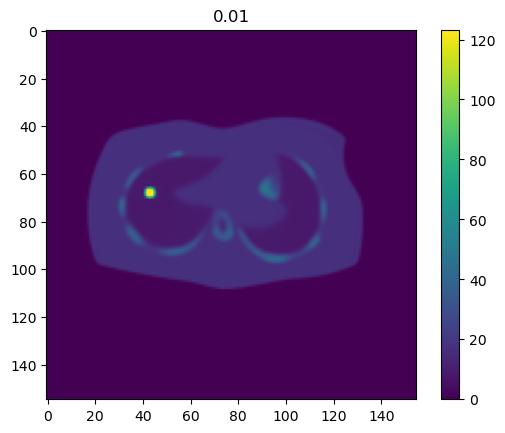

In [ ]:
gamma = 1e-2 # gamma controls the level of regularization (higher gamma = smoother reconstruction)

sigma = gamma*ones_data/acq_model.get_linear_acquisition_model().forward(ones_image)
tau = 1/gamma*ones_image/acq_model.backward(ones_data)

g = DRUNetPnP(
    sigma=3.0,  # sigma is the noise level expected by the DRUNet;
    clamp=True  # a more sophisticated implementation would vary sigma by iteration.
)

def do_nothing(self):
    return 0.
setattr(PDHG, 'update_objective', do_nothing)

# Setup and run PDHG

pdhg = PDHG(f=f, g=g, operator=K, sigma=sigma, tau=tau, 
            update_objective_interval = 4, 
            check_convergence=False)

pdhg.run(50)

pdhg_recon = pdhg.get_output()   

plt.imshow(pdhg_recon.as_array()[0,:,:])
plt.colorbar()
plt.title(gamma)
plt.show()

## Compare to conventional OSEM reconstruction

In [ ]:
# --- OSEM reconstruction ---

# OSEM setup
num_subsets = 4
num_subiterations = 100

osem_obj_fun = pet.make_Poisson_loglikelihood(acquired_data)
osem_obj_fun.set_acquisition_model(acq_model)

osem = pet.OSMAPOSLReconstructor()
osem.set_objective_function(osem_obj_fun)
osem.set_num_subsets(num_subsets)
osem.set_num_subiterations(num_subiterations)

osem_initial = ground_truth.get_uniform_copy(ground_truth.max() * 0.15)
make_cylindrical_fov(osem_initial)

osem.set_current_estimate(osem_initial)
osem.set_up(osem_initial)
osem.process()

osem_recon = osem.get_output()

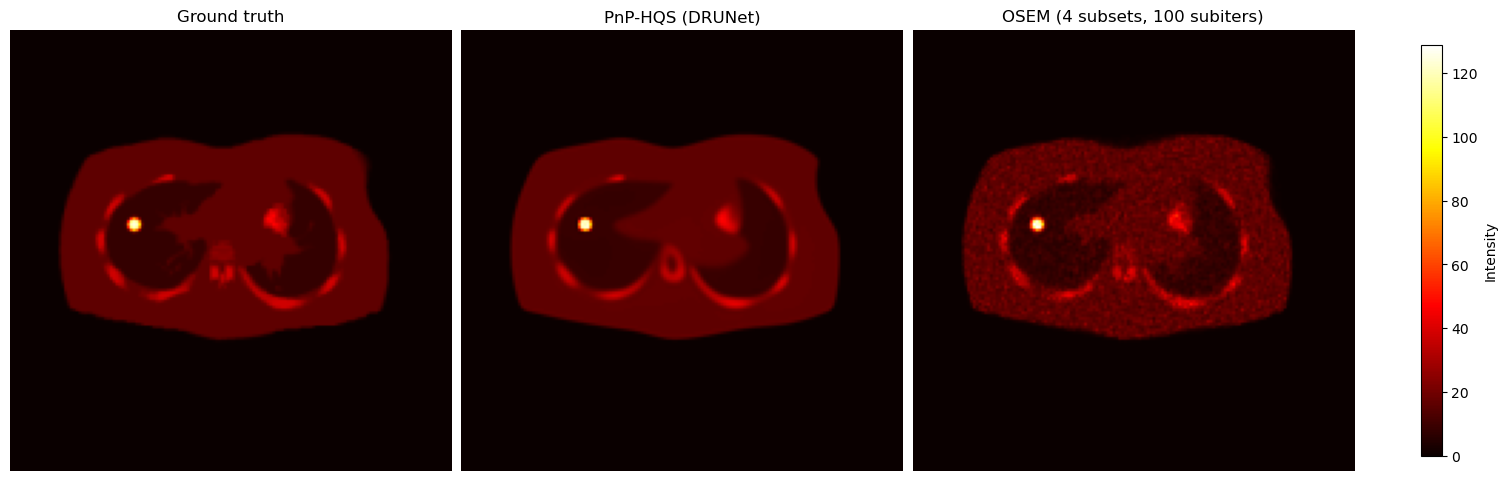

In [9]:
# --- comparison plot with matched scaling ---
# arrays
gt_arr = ground_truth.as_array()[0, :, :]
pnp_arr = pdhg_recon.as_array()[0, :, :]
osem_arr = osem_recon.as_array()[0, :, :]

# common scaling
vmin = 0.0
vmax = max(gt_arr.max(), pnp_arr.max(), osem_arr.max())

cmap = "hot"

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

im0 = axes[0].imshow(gt_arr, cmap=cmap, vmin=vmin, vmax=vmax)
axes[0].set_title('Ground truth')
axes[0].axis('off')

im1 = axes[1].imshow(pnp_arr, cmap=cmap, vmin=vmin, vmax=vmax)
axes[1].set_title('PnP-HQS (DRUNet)')
axes[1].axis('off')

im2 = axes[2].imshow(osem_arr, cmap=cmap, vmin=vmin, vmax=vmax)
axes[2].set_title(f'OSEM ({num_subsets} subsets, {num_subiterations} subiters)')
axes[2].axis('off')

cbar = fig.colorbar(im2, ax=axes, shrink=0.85)
cbar.set_label('Intensity')

plt.show()